# 1. Preparation
---
## 1.1 Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from utils.randimage import RandomLinesGenerator
from pathlib import Path
import os

## 1.2 Constant utilities

In [2]:
# Setting torch seed
RANDOM_SEED = 42
torch.manual_seed(42)

In [3]:
device = torch.accelerator.current_accelerator(check_available=True)
if device is None:
    device = torch.device('cpu')

print(f"Chosen device: {device}{':'+device.index if device.index is not None else ''}")

# CUDA Optimizations
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True  # Auto-tune convolution algorithms
    torch.backends.cudnn.enabled = True
    print("CUDNN optimizations enabled")
else:
    print("Running on CPU - CUDA optimizations disabled")

Chosen device: cuda
CUDNN optimizations enabled


## 1.3 Dataset Augmentation
### 1.3.1 Create blanks
Additional dataset containing images which are mostly blank or have random pencil strokes

In [4]:
MNIST_PATH = Path("datasets/MNIST")
BLANK_DATASET_PATH = Path("datasets/Blanks")
BLANKS_PATH = BLANK_DATASET_PATH / 'blank'

os.makedirs(MNIST_PATH, exist_ok=True)

for i in range(0, 10):
    os.makedirs(BLANK_DATASET_PATH / str(i), exist_ok=True)

os.makedirs(BLANKS_PATH, exist_ok=True)

# blanks_generator = RandomLinesGenerator() # calling this generates an image
# # we want to generate around 8000 images in order to have balanced dataset
# # training <- 7000
# # testing <- 1000
# for i in range(8000): 
#     torchvision.utils.save_image(blanks_generator(), BLANKS_PATH / f"img{i}.png")


### 1.3.2 Load datasets

In [5]:
# Data Augmentation - Apply RandomRotation, RandomAffine and ElasticTransform to train dataset
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    torchvision.transforms.Grayscale(num_output_channels=1),
    torchvision.transforms.ToTensor()
])

# Preserve test dataset clean without any transform effects applied
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Grayscale(num_output_channels=1),
    torchvision.transforms.ToTensor()
])

In [6]:
blank_dataset = torchvision.datasets.ImageFolder(
    BLANK_DATASET_PATH,
    allow_empty=True,
    transform=train_transform
)

generator = torch.Generator()

blank_train, blank_test = torch.utils.data.random_split(blank_dataset, [7/8, 1/8])

train_MNIST = torchvision.datasets.MNIST(
    MNIST_PATH, train=True, transform=train_transform, download=True
)

test_MNIST = torchvision.datasets.MNIST(
    MNIST_PATH, train=False, transform=test_transform, download=True
)

full_train_dataset = torch.utils.data.ConcatDataset([train_MNIST, blank_train])
full_test_dataset =  torch.utils.data.ConcatDataset([test_MNIST, blank_test])

# Split train dataset into train subset and validation subset
train_subset, val_subset = torch.utils.data.random_split(
    full_train_dataset, [0.8, 0.2], generator=generator
)

print(len(train_subset))
print(len(val_subset))
print(len(full_test_dataset))

53600
13400
11000


In [7]:
# Loaders Parameters
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_TEST = 512
NUM_WORKERS = 4

# Enable pin_memory for CUDA to speed up data transfer
PIN_MEMORY = device.type == 'cuda'

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=BATCH_SIZE_TRAIN, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

val_loader = torch.utils.data.DataLoader(
    val_subset, batch_size=BATCH_SIZE_TRAIN, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

test_loader = torch.utils.data.DataLoader(
    test_MNIST, batch_size=BATCH_SIZE_TEST, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

In [8]:
print(torch.max(full_train_dataset[0][0]).item())
print(full_train_dataset[0][0].shape)

1.0
torch.Size([1, 28, 28])



### Examples

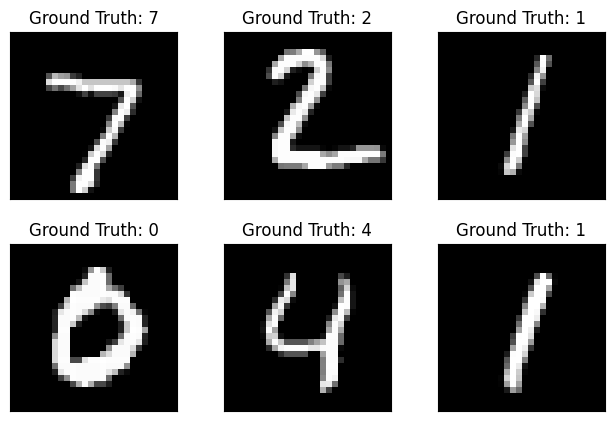

In [9]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    plt.title("Ground Truth: {}".format(example_targets[i]))
    plt.xticks([])
    plt.yticks([])
    
plt.show()

## Dataset statistis

In [10]:
# print(f"Images in train dataset:      {len(train_subset):>7}")
# print(f"Images in validation dataset: {len(val_subset):>7}")
# print(f"Images in test dataset:       {len(full_test_dataset):>7}")
# print()

# def make_datasets_statistics(*datasets):
#     counter = {}
#     for dataset_i, dataset in enumerate(datasets):
#         print(f'Checking dataset {dataset_i}')
#         for idx, tup in enumerate(dataset):
#             if tup[1] not in counter.keys():
#                 counter[tup[1]] = 0
            
#             counter[tup[1]] += 1
            
#             if(idx % 500 == 0):
#                 print(f"Checked {idx}/{len(dataset)}\r", end='')
#         print(f"Checked {len(dataset)}/{len(dataset)}")

#     return counter

# # This can take up to 10 mins depending on you machine
# statistics = make_datasets_statistics(train_subset, val_subset, full_test_dataset)

# plt.cla()

# # vals = [statistics[k] for k in sorted(statistics.keys())]
# # plt.bar(list(sorted(statistics.keys())), [statistics[k] for k in sorted(statistics.keys())])

# # os.makedirs('statstics', exist_ok=True)
# # plt.savefig('statistics/dataset_statistics.png')

# # plt.show()

## Model declaration

In [11]:
from models_arch.Recognizer import RecognizerV3

model = RecognizerV3()
model = model.to(device)
print(model)
print(device)

RecognizerV3(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Dropout(p=0.3, inplace=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=784, out_features=64, bias=True)
  (11): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=64, out_features=11, bias=True)
)
cuda


## Training the model

=========== Epoch 1/20 ===========
End of Epoch 1. Training Loss: 0.63357. Validation Loss: 0.31598
=========== Epoch 2/20 ===========
End of Epoch 2. Training Loss: 0.40661. Validation Loss: 0.20938
=========== Epoch 3/20 ===========
End of Epoch 3. Training Loss: 0.26767. Validation Loss: 0.16355
=========== Epoch 4/20 ===========
End of Epoch 4. Training Loss: 0.23901. Validation Loss: 0.13287
=========== Epoch 5/20 ===========
End of Epoch 5. Training Loss: 0.31433. Validation Loss: 0.11743
=========== Epoch 6/20 ===========
End of Epoch 6. Training Loss: 0.17944. Validation Loss: 0.11097
=========== Epoch 7/20 ===========
End of Epoch 7. Training Loss: 0.25842. Validation Loss: 0.10370
=========== Epoch 8/20 ===========
End of Epoch 8. Training Loss: 0.33910. Validation Loss: 0.09855
=========== Epoch 9/20 ===========
End of Epoch 9. Training Loss: 0.23084. Validation Loss: 0.09843
=========== Epoch 10/20 ===========
End of Epoch 10. Training Loss: 0.28133. Validation Loss: 0.0938

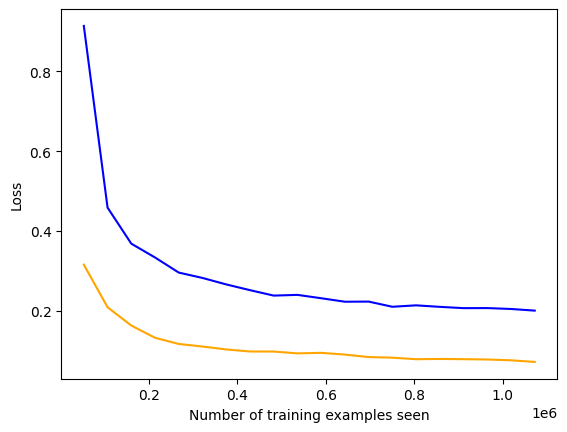

In [12]:
# Hyperparameters
epochs = 20
learning_rate = 0.001

# Initialize the model (try to use discrete GPU)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
counter = []

for epoch in range(epochs):
    model.train()
    print(f"=========== Epoch {epoch + 1}/{epochs} ===========")

    data: torch.Tensor
    label: torch.Tensor

    epoch_train_loss = 0
    for batch_idx, (data, label) in enumerate(train_loader):
        # Copy tensors into GPU with non_blocking for async transfer
        data, label = data.to(device, non_blocking=True), label.to(device, non_blocking=True)

        optimizer.zero_grad()
        
        preds = model(data)
        loss = loss_fn(preds, label)
        epoch_train_loss += loss.item()
        
        loss.backward()
        optimizer.step()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)
    counter.append((epoch+1) * len(train_loader.dataset))

    # Validate
    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for data, label in val_loader:
            # Copy data into GPU with non_blocking
            data, label = data.to(device, non_blocking=True), label.to(device, non_blocking=True)
            
            preds = model(data)
            epoch_val_loss += loss_fn(preds, label).item()

    # Average validation loss for an epoch
    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"End of Epoch {epoch + 1}. Training Loss: {loss.item():.5f}. Validation Loss: {epoch_val_loss:.5f}")
    
plt.cla()
plt.plot(counter, train_losses, color='blue')
plt.plot(counter, val_losses, color='orange')
plt.xlabel('Number of training examples seen')
plt.ylabel('Loss')
plt.show()

## Saving a model


In [13]:
torch.save(model.state_dict(), "trained_models/RecognizerV31.pth")

## Testing a model



Test set: Avg. loss: 0.0001, Accuracy: 9890/10000 (99%)



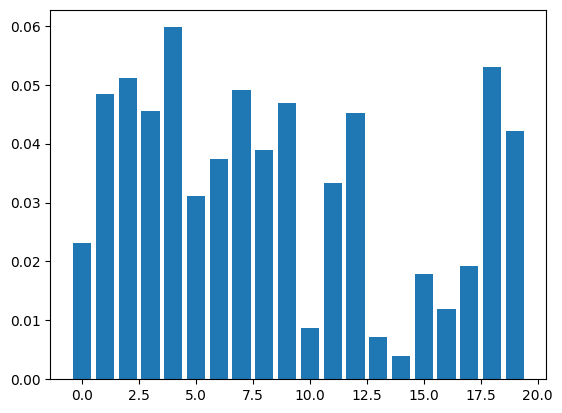

In [14]:
test_losses = []

test_loss = 0
correct = 0

model.eval()
with torch.no_grad():
    for data, label in test_loader:
        # Copy data into GPU with non_blocking
        data, label = data.to(device, non_blocking=True), label.to(device, non_blocking=True)
        
        preds: torch.Tensor = model(data)

        test_loss += loss_fn(preds, label).item()
        pred = preds.data.max(1, keepdim=True)[1]

        correct += pred.eq(label.data.view_as(pred)).sum()

        test_losses.append(loss_fn(preds, label).item())

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(test_loss, correct,
                                                                              len(test_loader.dataset),
                                                                              100. * correct / len(
                                                                                  test_loader.dataset)))

counter = np.arange(len(test_losses))
plt.bar(counter, test_losses)
plt.show()